In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\archive (2)\Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.drop(["PassengerId","Name","Ticket","Cabin"],axis=1,inplace=True)

In [7]:
df["Age"].fillna(df["Age"].median(),inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12700\735977717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_12700\735977717.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [8]:
encoder=LabelEncoder()

df["Sex"]=encoder.fit_transform(df["Sex"])

df["Embarked"]=encoder.fit_transform(df["Embarked"])

In [9]:
X=df.drop("Survived",axis=1)

y=df["Survived"]

In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model=LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
prediction=model.predict(X_test)

In [15]:
print("Accuracy:",accuracy_score(y_test,prediction))

print("Precision:",precision_score(y_test,prediction))

print("Recall:",recall_score(y_test,prediction))

print("F1 Score:",f1_score(y_test,prediction))

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888


In [14]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



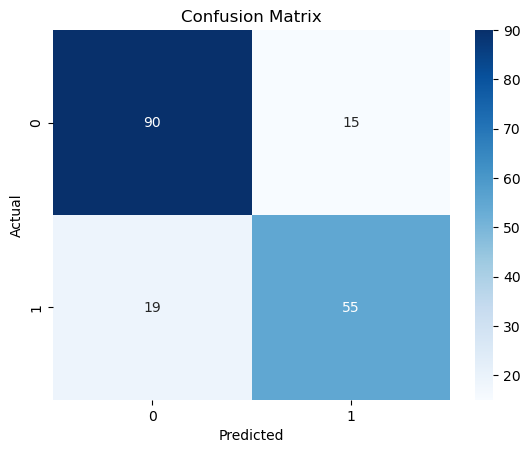

In [16]:
cm=confusion_matrix(y_test,prediction)

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show() 

In [17]:
tree=DecisionTreeClassifier(random_state=42)

tree.fit(X_train,y_train)

tree_prediction=tree.predict(X_test)

In [18]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test,tree_prediction))

Decision Tree Accuracy: 0.7821229050279329


In [19]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test,prediction))

print("Decision Tree Accuracy:",
      accuracy_score(y_test,tree_prediction))

Logistic Regression Accuracy: 0.8100558659217877
Decision Tree Accuracy: 0.7821229050279329


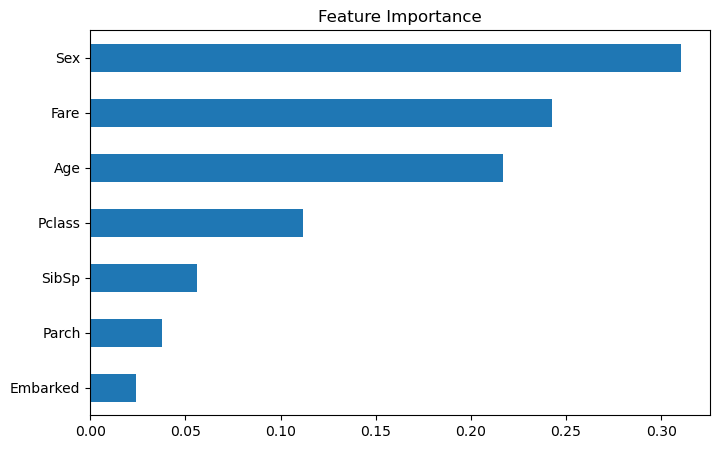

In [20]:
importance=pd.Series(
    tree.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

In [21]:
import joblib

joblib.dump(model,"classification_model.pkl")

['classification_model.pkl']

# Model Performance

A Logistic Regression model was trained to predict passenger survival using the Titanic dataset. The dataset was cleaned by handling missing values and encoding categorical variables. The model was evaluated using Accuracy, Precision, Recall, and F1 Score.

The Logistic Regression model performed well on this dataset because the target variable is binary and the relationship between several features and survival is reasonably separable. A Decision Tree model was also trained for comparison. Future improvements could include feature engineering, hyperparameter tuning, or using ensemble methods such as Random Forest or Gradient Boosting. 